# Kapitel 5 - Koduppgift 8: PCA Kodförklaring

I denna uppgift förklarar vi vad den givna PCA-koden gör steg för steg.

## Den givna koden

Här är koden som vi ska förklara:

In [1]:
import numpy as np
from sklearn.decomposition import PCA

# Creating a dataset with 3 features/columns
X = np.random.rand(1000, 3)
print(X[0:5])
# Reducing the data to 2 dimensions
pca = PCA(n_components=2)
X2D = pca.fit_transform(X)
print(X2D[0:5])

# "Recreating" the data to 3 dimensions
X3D_inv = pca.inverse_transform(X2D)
# Not exactly equal since some information was lost in the transformation
print(np.allclose(X3D_inv, X))

[[0.43465545 0.78723781 0.71247443]
 [0.78596364 0.06160192 0.39498644]
 [0.8740485  0.30495556 0.66357064]
 [0.5271024  0.12929859 0.56898382]
 [0.67055515 0.65099549 0.85764964]]
[[ 0.34586425 -0.03813244]
 [-0.46013364  0.27974433]
 [-0.11745701  0.42098763]
 [-0.26656344  0.16268922]
 [ 0.29783152  0.26679265]]
False


## Steg-för-steg förklaring

Låt oss gå igenom varje del av koden:

### Steg 1: Importera bibliotek

In [2]:
import numpy as np
from sklearn.decomposition import PCA

print('Bibliotek importerade!')
print('numpy: För numeriska beräkningar och array-hantering')
print('PCA: Principal Component Analysis från scikit-learn')

Bibliotek importerade!
numpy: För numeriska beräkningar och array-hantering
PCA: Principal Component Analysis från scikit-learn


### Steg 2: Skapa syntetisk dataset

In [3]:
# Skapa ett dataset med 1000 rader och 3 kolumner (features)
np.random.seed(42)  # För reproducerbara resultat
X = np.random.rand(1000, 3)

print(f'Dataset shape: {X.shape}')
print(f'Antal rader: {X.shape[0]}')
print(f'Antal kolumner: {X.shape[1]}')
print('\nFörsta 5 rader:')
print(X[0:5])

print('\nFörklaring:')
print('- np.random.rand() skapar slumpmässiga tal mellan 0 och 1')
print('- (1000, 3) betyder 1000 rader och 3 kolumner')
print('- X[0:5] visar de första 5 raderna')

Dataset shape: (1000, 3)
Antal rader: 1000
Antal kolumner: 3

Första 5 rader:
[[0.37454012 0.95071431 0.73199394]
 [0.59865848 0.15601864 0.15599452]
 [0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]
 [0.83244264 0.21233911 0.18182497]]

Förklaring:
- np.random.rand() skapar slumpmässiga tal mellan 0 och 1
- (1000, 3) betyder 1000 rader och 3 kolumner
- X[0:5] visar de första 5 raderna


### Steg 3: Applicera PCA

In [4]:
# Skapa PCA-objekt som reducerar till 2 dimensioner
pca = PCA(n_components=2)

print('PCA-objekt skapat!')
print('n_components=2 betyder att vi vill behålla 2 huvudkomponenter')
print('Detta reducerar vår data från 3D till 2D')

PCA-objekt skapat!
n_components=2 betyder att vi vill behålla 2 huvudkomponenter
Detta reducerar vår data från 3D till 2D


In [5]:
# Träna PCA-modellen och transformera data
X2D = pca.fit_transform(X)

print(f'Data efter PCA: {X2D.shape}')
print('\nFörsta 5 rader efter PCA:')
print(X2D[0:5])

print('\nFörklaring:')
print('- fit_transform() tränar PCA-modellen och transformerar data')
print('- Data har nu 2 kolumner istället för 3')
print('- Varje rad representerar samma datapunkt men i 2D-rymd')

Data efter PCA: (1000, 2)

Första 5 rader efter PCA:
[[ 0.45459779  0.05941797]
 [-0.36808474 -0.19497059]
 [ 0.28700506 -0.14996497]
 [-0.33376092  0.61290315]
 [-0.26264222 -0.10302082]]

Förklaring:
- fit_transform() tränar PCA-modellen och transformerar data
- Data har nu 2 kolumner istället för 3
- Varje rad representerar samma datapunkt men i 2D-rymd


### Steg 4: Förklarad varians

In [6]:
# Visa hur mycket varians som förklaras av varje komponent
explained_variance = pca.explained_variance_ratio_
total_variance = pca.explained_variance_ratio_.sum()

print('Förklarad varians per komponent:')
for i, var in enumerate(explained_variance):
    print(f'PC{i+1}: {var:.3f} ({var*100:.1f}%)')

print(f'\nTotal förklarad varians: {total_variance:.3f} ({total_variance*100:.1f}%)')
print(f'Information som förloras: {(1-total_variance)*100:.1f}%')

Förklarad varians per komponent:
PC1: 0.345 (34.5%)
PC2: 0.336 (33.6%)

Total förklarad varians: 0.681 (68.1%)
Information som förloras: 31.9%


### Steg 5: Inverse transform

In [7]:
# Försök att återskapa originaldata från PCA-data
X3D_inv = pca.inverse_transform(X2D)

print(f'Återskapad data shape: {X3D_inv.shape}')
print('\nFörsta 5 rader av återskapad data:')
print(X3D_inv[0:5])

print('\nFörklaring:')
print('- inverse_transform() försöker återskapa originaldata')
print('- Men eftersom vi förlorade information (1 komponent) blir det inte exakt samma')

Återskapad data shape: (1000, 3)

Första 5 rader av återskapad data:
[[0.62343309 0.91834955 0.62721367]
 [0.37026666 0.18571753 0.25214411]
 [0.51663877 0.806548   0.40807005]
 [0.66024712 0.02680347 0.99004366]
 [0.42351359 0.26551413 0.35397807]]

Förklaring:
- inverse_transform() försöker återskapa originaldata
- Men eftersom vi förlorade information (1 komponent) blir det inte exakt samma


### Steg 6: Jämförelse

In [8]:
# Kontrollera om återskapad data är lika med originaldata
are_equal = np.allclose(X3D_inv, X)
print(f'Är återskapad data lika med originaldata? {are_equal}')

# Visa skillnaden
difference = np.abs(X3D_inv - X)
print(f'\nGenomsnittlig skillnad per element: {difference.mean():.6f}')
print(f'Maximal skillnad: {difference.max():.6f}')

print('\nFörklaring:')
print('- np.allclose() kontrollerar om arrays är nästan lika (med tolerans)')
print('- False betyder att de inte är exakt lika')
print('- Detta är förväntat eftersom vi förlorade information i PCA')

Är återskapad data lika med originaldata? False

Genomsnittlig skillnad per element: 0.114132
Maximal skillnad: 0.600752

Förklaring:
- np.allclose() kontrollerar om arrays är nästan lika (med tolerans)
- False betyder att de inte är exakt lika
- Detta är förväntat eftersom vi förlorade information i PCA


## Visualisering av processen

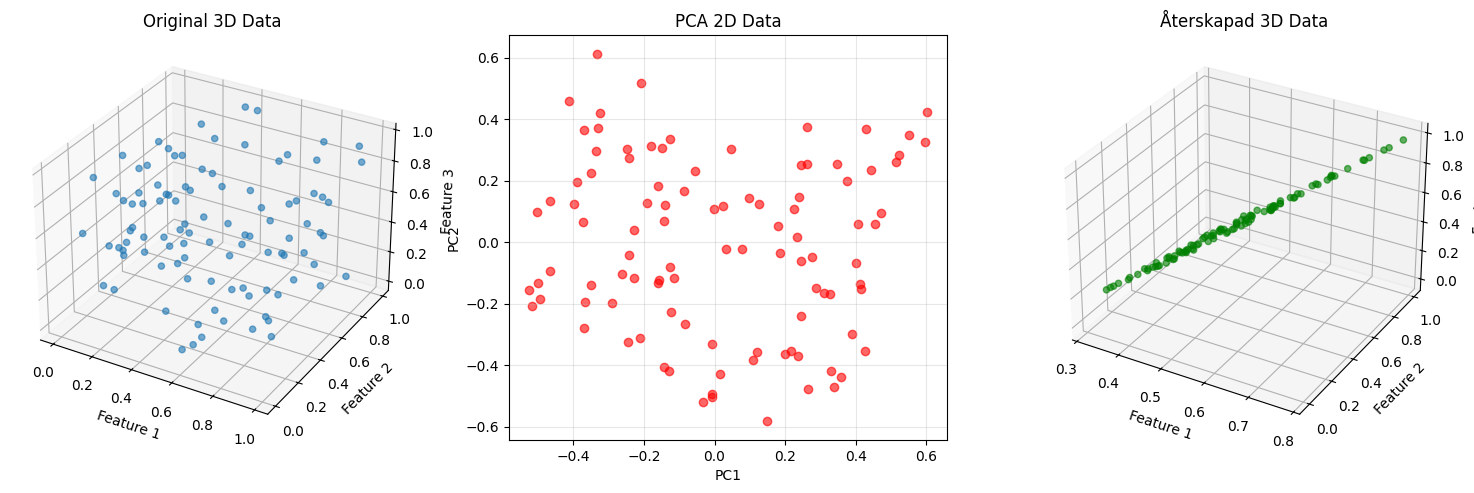

In [9]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Skapa figur med subplots
fig = plt.figure(figsize=(15, 5))

# Original 3D data
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X[:100, 0], X[:100, 1], X[:100, 2], alpha=0.6)
ax1.set_title('Original 3D Data')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.set_zlabel('Feature 3')

# PCA 2D data
ax2 = fig.add_subplot(132)
ax2.scatter(X2D[:100, 0], X2D[:100, 1], alpha=0.6, color='red')
ax2.set_title('PCA 2D Data')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.grid(True, alpha=0.3)

# Återskapad 3D data
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X3D_inv[:100, 0], X3D_inv[:100, 1], X3D_inv[:100, 2], alpha=0.6, color='green')
ax3.set_title('Återskapad 3D Data')
ax3.set_xlabel('Feature 1')
ax3.set_ylabel('Feature 2')
ax3.set_zlabel('Feature 3')

plt.tight_layout()
plt.show()

## Sammanfattning av vad koden gör

**Hela processen i korthet:**

1. **Skapar syntetisk data** - 1000 datapunkter med 3 features
2. **Applicerar PCA** - Reducerar från 3D till 2D genom att hitta huvudkomponenter
3. **Förlorar information** - Eftersom vi reducerar dimensioner förlorar vi information
4. **Återskapar data** - Försöker återskapa originaldata från PCA-data
5. **Verifierar skillnad** - Kontrollerar att återskapad data inte är exakt lika

**Viktiga lärdomar:**
- PCA reducerar dimensioner men förlorar information
- `inverse_transform()` kan inte återskapa exakt samma data
- `np.allclose()` är användbart för att jämföra numeriska arrays
- Dimensionsreducering är en kompromiss mellan enkelhet och information